---
# **Análisis y Predicción de la Viralidad del Contenido de TikTok mediante Machine Learning** 

### Trabajo de Fin de Máster - Universidad de Madrid (UCM)

**Autora:** Rocío Pérez Holgado

---
## **ESTRUCTURA DEL PROYECTO**

* **Cuaderno 1:** `01_Carga_Exploracion_y_Limpieza.ipynb` **(Este cuaderno)**.
* **Cuaderno 2:** `02_Analisis_Exploratorio_EDA.ipynb`.
* **Cuaderno 3:** `03_Feature_Engineering_y_Modelado.ipynb`.

---
## **Introducción y Objetivos** 
En este primer cuaderno vamos a llevar a cabo la primera fase del proyecto. A partir de los datasets originales en formato Parquet sobre los creadores, publicaciones y engagment diario de TikTok, se visualizará y analizará su estructura y contenido para poder identificar y tratar los diferentes errores de integridad, como datos faltantes, errores de tipología de datos, etc. 

Como resultado final, obtendremos tres tablas nuevas limpias de cualquier tipo de fallo. Estas tablas las tendremos que exportar a formato Parquet, para no reescribir los datos originales y poder tenerlos como base para las siguientes fases del proyecto.

* **Datasets resultantes generados:**
    * `videos_clean.parquet`.
    * `engagement_clean.parquet`.
    * `creators_clean.parquet`.

---
## **Índice - Cuaderno 1:**
1. **Importación de Librerías**.
2. **Carga y Descripción de los Datasets**.
   * 2.1. Estructura de los Datasets.
   * 2.2. Carga de los Datasets.
   * 2.3. Diccionario de Datos.
4. **Exploración Inicial de los Datos**.
5. **Preprocesamiento y Limpieza de Datos**.

---
## **1. Importación de Librerías**

In [2]:
import os
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

---
## 2. **Carga y Descripción de los Datasets**

#### **2.1. Estructura de los Datasets**
---
El conjunto de datos en el que trabajaremos en este notebook, esta basado en tres tablas enlazadas que se han obtenido a partir de los diferentes archivos Parquet.

**`videos`**:
* Características estáticas de los vídeos publicados.
* Cada fila representa un vídeo único.
* Dos claves foráneas representa el enlace con la tabla `creator_daily`.
* Clave primaria:
    * `video_id`.
* Clave foránea:
    * `author_id` (enlaza con la tabla `creator_daily`).
* Ventana de observación:
    * 2024-06-24 a 2024-12-09.

**`engagement_daily`**:
* Métricas sobre el rendimiento y las interacciones diarias de los vídeos.
* Cada fila representa el rendimiento de un vídeo en un día determinado.
* Clave primaria compuesta:
    * {`video_id`, `date`}.
* Clave fóranea:
    * `video_id` (enlaza con la tabla `videos`).
          
**`creator_daily`**:
* Métricas y evolución diaria de los creadores de contenido.
* Cada fila representa el estado de un perfil en un día determinado.
* Clave primaria compuesta:
    * {`author_id`, `date`}.

Las dos últimas tablas representan series temporales registradas en la misma ventana temporal: 2024-06-24 a 2024-12-09.

#### **2.2. Carga de los Datasets**
---

In [3]:
videos_df = pd.read_parquet("../datos/videos.parquet")
engagement_df = pd.read_parquet("../datos/engagement_daily.parquet")
creator_df = pd.read_parquet("../datos/creator_daily.parquet")

#### **2.3. Diccionario de Datos**
---

#### **Tabla `videos`**

* **video_id:** Id. del vídeo.
* **author_id:** Id. del creador.
* **create_time, create_date:** Marca de tiempo y fecha de creación.
* **duration:** Duración del vídeo en segundos.
* **ratio:** Calidad del vídeo.
* **desc_language:** Idioma detectado en la descripción del vídeo.
* **is_english:** Indicador binario que señala si la descripción está en inglés (1/True).
* **desc:** Descripción del vídeo escrita por el usuario.
* **sticker_text:** Texto incrustado visualmente en el vídeo mediante la edicción de TikTok.
* **hashtags:** Lista de hashtags adjuntos en formato objeto: **{hashtags_id, hashtags_name}**.
* **created_by_ai:** Indicador binario que señala si el vídeo fue creado o editado por la IA (1/True).
* **is_ads:** Indicador binario sobre si es contenido publicitario (1/True).
* **music_selected_from:** Origen del audio (Ej. librería de TikTok, audio original creado por un usuario, ...).
* **music_album:** Nombre del albúm al que pertenece el audio.
* **music_author:** Nombre del artista, compositor o cuenta creadora del audio.
* **music_owner_id:** Id. de la cuenta de TikTok propietaria del audio.
* **music_id:** Id. de la canción.
* **music_title:** Título de la canción.
* **transcript:** Transcripción del texto del audio.
* **word_count:** Número total de palabras que contiene la descripción.
* **emoji_count:** Número de emojis incluidos en el texto de la descripción.
* **question_count:** Cantidad de signos de interrogación o preguntas formuladas.
* **hashtag_count:** Número total de hashtags.
* **speaking_rate:** Velocidad del audio.
* **gpt_summary:** Resumen del vídeo generado de forma automática.
* **topic:** Categoría temática del vídeo:
    * **Beauty/Fashion** (*Belleza/Moda*).
    * **Others** (*Otros*).
    * **Life hacks/Personal growth** (*Trucos de vida/Crecimiento personal*).
    * **Lifestyle** (*Estilo de vida*).
    * **Dance/Music** (*Bailar/Música*).
    * **Sport/Fitness** (*Deporte/Fitness*).
    * **Cooking/Food** (*Cocina/Comida*).
    * **Shopping/Products** (*Compras/Productos*).
    * **Movies/TV/Books** (Peliculas/TV/Libros).
* **anger, joy, surprise, sadness, disgust, fear:** Probabilidad (valores del 0 al 1) de las emociones detectadas en el texto de la descripción de cada vídeo. Estos datos han sido calculados por una IA de análisis de sentimientos (NLP).

---

#### **Tabla `engagement_daily`**

* **video_id:** Id. del vídeo.
* **date:** Fecha en la que se tomaron las últimas mediciones.
* **days_since_post:** Cantidad de días transcurridos desde la fecha de publicación hasta el día en el que se tomaron las últimas medidas.
* **play_count:** Número de visualizaciones .
* **like_count:** Número de likes o me gustas.
* **comment_count:** Cantidad de comentarios.
* **share_count:** Número de veces que los usuarios han compartido el vídeo, tanto fuera como dentro de la aplicación.
* **collect_count:** Cantidad de veces que ha sido guardado.
* **whatsapp_share_count:** Número de veces que el vídeo ha sido compartido, a través de la aplicación WhatsApp.

---

#### **Tabla `creator_daily`**

* **author_id:** Id. del creador.
* **date:** Fecha en la que se registraron los últimos datos del creador.
* **follower_count:** Número de seguidores.
* **following_count:** Cantidad de personas a las que sigue.
* **total_favorited:** Total de me gustas o likes recibidos.
* **video_count:** Total de vídeos publicados.
* **enterprise_verified:** Indica si es un perfil corporativo o de empresa verificada por TikTok (1/True) o una cuenta personal o creador individual (0/False).

---
## **3. Exploración Inicial de los Datos**

En esta fase se realiza un primer análisis exploratorio con el fin de comprender la estructura de los datasets y evaluar la calidad de su contenido. Este análisis se hace con el objetivo de identificar las necesidades de acondicionamiento que se corregirán en el punto 4. 

#### **3.1. Dimensiones de los Datasets**
---

In [7]:
print("videos:", videos_df.shape)
print("engagement:", engagement_df.shape)
print("creator_df:", creator_df.shape)

videos: (209543, 33)
engagement: (6068955, 10)
creator_df: (278433, 7)


* `videos`: 209.543 filas (registros) y 33 columnas (variables).
* `engagement`: 6.068.955 filas (registros) y 10 columnas (variables).
* `creator`: 278.433 filas (registros) y 7 columnas (variables).

#### **3.2. Visualización de los Datos**
---

Se muestra una vista previa de las primeras filas de cada dataset para verificar la correcta carga de los datos.

In [6]:
videos_df.head()

,video_id,author_id,create_time,create_date,duration,ratio,desc_language,is_english,desc,sticker_text,...,hashtag_count,speaking_rate,gpt_summary,topic,anger,joy,surprise,sadness,disgust,fear
0,7386493327656504607,6958316329012003846,2024-06-30 21:46:54,2024-06-30,20.067,540p,un,0,#fallowme #foryoupage #fyp #fypp #goodengery #...,NaN,...,14.0,0.000000,"In this short video, the creator is seen in a ...",Lifestyle,0.007287,0.427565,0.004642,0.011638,0.154876,0.001623
1,7386314758808522014,6958316329012003846,2024-06-30 10:14:14,2024-06-30,83.100,540p,un,0,#fyp #foryoupage #fallowme #TikTokShop #newdro...,new drop coming,...,7.0,0.000000,The video showcases a vibrant collection of un...,Beauty_Fashion,0.003728,0.850722,0.009022,0.003120,0.008401,0.000587
2,7387143945744141599,6958316329012003846,2024-07-02 15:51:42,2024-07-02,26.634,540p,un,0,#goodengery #packages #sample #mail #fyppppppp...,NaN,...,5.0,5.894721,"In this short video, the creator humorously re...",Life_hacks_Personal_growth,0.318762,0.197186,0.013447,0.051367,0.118099,0.000834
3,7386071738137709854,6964376699194868741,2024-06-29 18:30:59,2024-06-29,15.282,540p,en,1,This view is next level 🔥 (via PeteBlackburn/X...,NHL Draft held at the Sphere in Las Vegas 🤯,...,4.0,1.832221,The video showcases the 2024 NHL Draft taking ...,Sports_Fitness,0.002147,0.950365,0.007567,0.001354,0.002758,0.001374
4,7385705954974698783,6964376699194868741,2024-06-28 18:51:22,2024-06-28,27.634,540p,en,1,Anaheim Ducks draft pick Beckett Sennecke was ...,He couldn't BELIEVE he \nwent #3 overall 😱,...,3.0,5.428096,"In this captivating video, the excitement surr...",Sports_Fitness,0.006035,0.046033,0.900363,0.000871,0.002806,0.014080


In [7]:
engagement_df.head()

,video_id,date,days_since_post,play_count,like_count,comment_count,share_count,collect_count,download_count,whatsapp_share_count
0,7381889522268654890,2024-06-25,0,1737,26,0,0,0,0,0
1,7381889522268654890,2024-06-26,1,1772,28,0,0,0,0,0
2,7381889522268654890,2024-06-27,2,1778,28,0,0,0,0,0
3,7381889522268654890,2024-06-28,3,1788,28,0,0,0,0,0
4,7381889522268654890,2024-06-29,4,1789,28,0,0,0,0,0


In [8]:
creator_df.head()

,author_id,date,follower_count,following_count,total_favorited,video_count,enterprise_verified
0,10245051,2024-06-27,1704.0,1039.0,75987,83.0,NaN
1,10245051,2024-06-28,1704.0,1039.0,76018,83.0,NaN
2,10245051,2024-06-29,1704.0,1039.0,76024,83.0,NaN
3,10245051,2024-06-30,1704.0,1039.0,76025,83.0,NaN
4,10245051,2024-07-01,1704.0,1039.0,76029,83.0,NaN


#### **3.3. Estructura y Tipos de Datos**
---

A continuación, se analiza la estructura de los datasets mediante `.info()` para examinar los tipos de datos asinados y la presencia de valores nulos. Esto permitirá identificar qué variables requieren una conversión de tipo o un tratamiento de limpieza de valores nulos en la siguiente etapa.

In [8]:
videos_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 209543 entries, 0 to 209542
Data columns (total 33 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   video_id             209543 non-null  str    
 1   author_id            209543 non-null  str    
 2   create_time          209543 non-null  str    
 3   create_date          209543 non-null  str    
 4   duration             209543 non-null  float64
 5   ratio                209543 non-null  str    
 6   desc_language        209543 non-null  str    
 7   is_english           209543 non-null  int64  
 8   desc                 190437 non-null  str    
 9   sticker_text         98833 non-null   str    
 10  hashtags             209543 non-null  object 
 11  created_by_ai        209542 non-null  float64
 12  is_ads               209543 non-null  str    
 13  music_selected_from  206770 non-null  str    
 14  music_album          47033 non-null   str    
 15  music_author         209183 

##### **Clasificación de variables:**
* **Variables identificativas:**
    * `video_id`, `author_id`, `music_id` y  `music_owner_id`
    * Almacenadas de forma correcta como `str`.
    * La única que debe ser valor único por fila es `video_id`.
          
* **Variables fecha/hora:**
    * `create_time` y `create_date`
    * Almacenadas como `str` pero deberían de ser de tipo `datetime`. Por tanto, necesitán una transformación de tipo. 
  
* **Variables dicotomicas:**
    * `is_english`, `created_by_ai` y `is_ads`
    * Tienen diferentes tipos de datos (`int64`, `float64`, `str`), se deberán de estandarizar a un tipo común (`int64`).

* **Variables cuantitativas:**
    * `duration`, `speaking_rate` y métricas de emoción (`anger`, `joy`, `surprise`, `sadness`, `disgust`, `fear`) almacenadas de forma corecta como `float64`
    * Las variables de recuento (`word_count`, `emoji_count`, `question_count` y `hashtag_count`) están como `float64` debido a la presencia de valores nulos (`NaN`). Se transformarán a tipo entero (`int64`) cuando hayamos tratado los nulos.
          
* **Variables cualitativas:**
    * `ratio`, `desc_language`, `desc`, `sticker_text`, `music_selected_from`, `music_album`, `music_author`, `music_title`, `transcript`, `gpt_summary` y `topic`
    * Almacenadas de forma correcta como `str`
          
* **Estructuras complejas:**
    * `hashtags` almacenada como una lista de objetos (`topic`).
    * Necesitará un desempaquetado y tratamiento especial.
      
##### **Valores nulos:**
* Múltiples variables con recuento de valores no nulos inferiores a 209.543.
* Requieren un análisis de patrones de ausencia y su posterior imputación o tratamiento correspondiente.

In [10]:
engagement_df.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 6068955 entries, 0 to 6068954
Data columns (total 10 columns):
 #   Column                Non-Null Count    Dtype
---  ------                --------------    -----
 0   video_id              6068955 non-null  str  
 1   date                  6068955 non-null  str  
 2   days_since_post       6068955 non-null  int64
 3   play_count            6068955 non-null  int64
 4   like_count            6068955 non-null  int64
 5   comment_count         6068955 non-null  int64
 6   share_count           6068955 non-null  int64
 7   collect_count         6068955 non-null  int64
 8   download_count        6068955 non-null  int64
 9   whatsapp_share_count  6068955 non-null  int64
dtypes: int64(8), str(2)
memory usage: 630.9 MB


##### **Clasificación de variables:**
* **Variables identificativas:**
    * `video_id`
    * Almacenadas de forma correcta como `str`.
    * El conjunto {`video_id`, `date`} debe ser único por fila. 
    
* **Variables fecha/hora:**
    * `date`
    * Almacenada como `str` pero deben de ser de tipo `datetime`. Por tanto, necesita una transformación de tipo. 

* **Variables cuantitativas:**
    * `days_since_post`, `play_count`, `like_count`, `comment_count`, `share_count`, `collect_count`, `download_count` y `whatsapp_share_count` almacenadas de forma corecta como `int64`
      
##### **Valores nulos:**
* Todas las variables representan 6.068.955 valores no nulos, por lo que no se observan valores ausentes en este conjunto de datos.

In [11]:
creator_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 278433 entries, 0 to 278432
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   author_id            278433 non-null  str    
 1   date                 278433 non-null  str    
 2   follower_count       278256 non-null  float64
 3   following_count      278256 non-null  float64
 4   total_favorited      278433 non-null  int64  
 5   video_count          278406 non-null  float64
 6   enterprise_verified  0 non-null       str    
dtypes: float64(3), int64(1), str(3)
memory usage: 22.0 MB


##### **Clasificación de variables:**
* **Variables identificativas:**
    * `author_id`
    * Almacenadas de forma correcta como `str`.
    * El conjunto {`author_id`, `date`} debe ser único por fila. 
          
* **Variables fecha/hora:**
    * `date`
    * Almacenada como str pero deben de ser de tipo datetime. Por tanto, necesita una transformación de tipo. 
  
* **Variables dicotomicas:**
    * `enterprise_verified`
    * Almacenada como `str` pero debe transformarse a entero (`int64`).

* **Variables cuantitativas:**
    * `total_favorited` está almacenado de forma correcta como `int64`.
    * `follower_count`, `following_count` y `video_count` están como `float64` debido a la presencia de valores nulos. Se transformarán a tipo entero (`int64`) cuando hayamos tratado los nulos. 
      
##### **Valores nulos:**
* Múltiples variables con recuento de valores no nulos inferiores a 278.433. 
* Destacable `enterprise_verified` con cero valores no nulos, por lo que, todos sus registros están vacíos. 

#### **3.4. Estadística Descriptiva**
---

En esta sección realizamos un análisis descriptivo de las variables para entender mejor la distribución y el comportamiento de los datos.

Este análisis será diferente para cada tipo de variable.

##### **Variables Cuantitativas**
Se realiza con la función `.describe()`. Esto genera un resumen estadístico con estas métricas:
* **`count` (Cantidad de registros):**
    * Indica el número de datos no nulos. 
* **`mean` (Media)**.
* **`std` (Desviación estándar):**
    * Mide que tán separados están los datos respecto a la media.
    * Si es un número muy grande, significa que los datos varían muchisimo entre si.
    * Si es un número pequeño, todos los datos están muy concentrados cerca de la media.
* **`min` y `max` (Mínimo y Máximo):**
    * Rango completo donde se mueven los datos.
* **`25%` y `75%` (Cuartiles):**
    * Dividen tus datos en cuatro partes iguales.
    * El primer cuartil (25%-Q1) indica que la cuarta parte de tus datos están por debajo de ese número.
    * El tercer cuartil (75% - Q3) indica que el 75% de los datos está por debajo de ese número.
* **`50%` (Mediana):**
    * Valor de en medio si ordenasemos todos los datos de menor a mayor.

Estas medidas nos permite detectar:

* **Asimetrías:**
    * Comparar `mean` y `50%`.
    * **Simétría (Media = Mediana):**
        * Distribución equilibrada.
    * **Asimetría negativa o a la izquierda (Media < Mediana):**
        * Mayoría de datos se agrupan en valores altos.
        * Valores atípicos o datos extremadamente bajos a la izquierda que bajan la media.
    * **Asímetría Positiva o a la Derecha (Mediana < Media):**
        * Mayoría de datos se agrupan en valores bajos.
        * Valores atípicos o datos extremadamente altos a la derecha que aumentan el promedio.
  
* **Valores atípicos (Outliers):**
    * Se detectan mirando la diferencia entre `25%` y `75%` respecto al `min` y `max`.
    * El `25%` y `75%` representa la zona donde están la mayoría de los datos, por tanto, si `min` y `max` están muy distanciados respecto a esa zona, significa que hay un outlier.
          
* **Variables con valores constantes:**
    * `std` = 0 o `min` = `max`.
    * Esto significa que todos los registros tienen  el mismo valor.
    * Este tipo de variable no importa y se puede eliminar.
          
* **Valores negativos donde no corresponden:**
    * `min` con valores negativos no permitidos.
          
* **Valores extremadamente altos o rangos inesperados:**
    * Observando `max` y `min` en variables con escalas acotadas.

Nota: Usamos la instrucción `.T` para mostrar las variables en filas en lugar de columnas para facilitar la interpretación.

In [10]:
videos_df.describe().T

,count,mean,std,min,25%,50%,75%,max
duration,209543.0,36.692008,35.683029,1.020000,11.634000,20.400000,57.267000,191.679000
is_english,209543.0,0.651604,0.476463,0.000000,0.000000,1.000000,1.000000,1.000000
created_by_ai,209542.0,0.005001,0.070544,0.000000,0.000000,0.000000,0.000000,1.000000
word_count,130034.0,62.966401,103.761772,0.000000,4.000000,17.000000,65.000000,1206.000000
emoji_count,130034.0,1.245259,2.350034,0.000000,0.000000,0.000000,2.000000,94.000000
question_count,130034.0,0.577418,1.674562,0.000000,0.000000,0.000000,0.000000,32.000000
hashtag_count,130034.0,5.936155,6.689154,0.000000,1.000000,4.000000,8.000000,119.000000
speaking_rate,130034.0,2.296959,2.893022,0.000000,0.000000,0.000000,5.048902,13.999806
anger,208565.0,0.026795,0.106627,0.000492,0.003467,0.005552,0.008983,0.992576
joy,208565.0,0.550233,0.358672,0.000236,0.158181,0.666798,0.891501,0.993037


**Métricas de duración y texto (`duration`, `word_count`, `hashtag_count`, ...):**
* **Asimetría positiva:**
    * La mayoría de los vídeos son breves y contienen poco texto tanto en la descripción como en el vídeo.
* **Presencia de valores atípicos (outliers):** 
    * Al comparar los rangos intercuartíliticos (25% - 75%) con los valores máximos, se detectan extremos muy distantes. 

**Métricas de dentimiento (`joy`, `anger`, `surprise`, ...):**
* **Predominio Emocional (`joy`):**
    * La emoción `joy` destaca con una media de 0.55 y una mediana de 0.67 sobre todas las demás variables.
    * Dataset dominado por contenido alegre.
* **Emociones negativas marginales:**
    * Los sentimientos negativos `anger`, `fear` o `surprise` presentan medianas extremedamente bajas (cercanas a 0.0), esto quiere decir que casi ningún vídeo transmite este tipo de emociones. 

**Métricas de audio y Texto (`speaking_rate`, `word_count`, `hashtag_count`, ...):**
* **Presencia de contenido silencioso:**
    * `speaking_rate` presenta valores 0.00 tanto en el primer percentil como en la mediana.
    * Más del 50% de los vídeos carecen de voz hablada.
* **Uso marginal de preguntas:**
    * `question_count` donde todos sus percentiles y la mediana es 0.
    * Esto quiere decir que al menos el 75% de todos los videos analizados tienen 0 preguntas o signos de interrogación.
    * Pero tenemos `max` a 32. Por tanto, el 25% de los videos restantes tiene una o más preguntas (llegando al caso extremo de 32).

In [43]:
engagement_df.describe().T

,count,mean,std,min,25%,50%,75%,max
days_since_post,6068955.0,14.590590,8.676324,0.0,7.0,14.0,22.0,30.0
play_count,6068955.0,24575.449643,257894.067904,0.0,314.0,570.0,2128.0,44442900.0
like_count,6068955.0,2126.356183,25545.904510,0.0,17.0,42.0,125.0,3044931.0
comment_count,6068955.0,32.048613,350.832496,0.0,0.0,3.0,10.0,67276.0
share_count,6068955.0,148.343629,3627.436106,0.0,0.0,0.0,3.0,991356.0
collect_count,6068955.0,139.905489,1914.782742,0.0,0.0,2.0,7.0,242201.0
download_count,6068955.0,12.648162,226.837998,0.0,0.0,0.0,1.0,42972.0
whatsapp_share_count,6068955.0,2.529477,76.092119,0.0,0.0,0.0,0.0,14159.0


**Asimetría positiva**
* La inmensa mayoría de los vídeos fracasan o tienen un alcance moderado. Ya que, la mediana dice que el 50% de los vídeos no supera las 570 reproducciones.

**Presencia masiva de outliers:**
* Estos outliers representan el famoso fénomeno al que le decimos viral.
* Este fénomeno se ve de forma muy clara al ver la gran distancia que hay entre el tercer cuartil y el valor máximo.
* Picos muy extremos como un vídeo con más de 44.4 millones de reproducciones (`max` de `play_count`) y más de 3 millones de me gustas (`max` de `like_count`).

**Desviaciones estándar desproporcionadas:**
* En todas las variables la desviación típica es mayor que la media, esto confirma la altísima dispersión de los datos. Esto también se debe a la viralidad de los vídeos.

**Comparación entre los valores medios/medianos de cada métrica respecto a las reproducciones (`play_count`):**
* **Ver un vídeo (`play_count` - Mediana = 570):**
    * Coste 0 porque es una acción pasiva (se reproduce solo).
* **Dar like (`like_count` - Mediana = 42):**
    * Coste muy bajo porque solo es tocar dos veces la pantalla.
* **Guardar y Comentar (`collect_count` - Mediana = 2 y `comment_count` - Mediana = 3):**
    * Coste medio porque exige detenerse a pensar antes de realizar la acción.
* **Compartir y Descargar (`share_count` - Mediana = 0, `whatsapp_share_count` - Mediana = 0, `download_count` - Mediana = 0):**
    * Coste extremo porque requiere salir de la aplicación (en caso de compartir por whatsapp) y buscar tu contacto.
    * En el otro caso, tiene ese mismo coste solo por pararte a pensar si quieres descargarlo en el teléfono y esperar a que la descarga se complete.
* **Conclusión:** Refleja cuanto le cuesta a cada usuario el realizar una acción con respecto a las visualizaciones (acción pasiva).

**Muestreo temporal balanceado:**
* `days_since_post` tiene como media 14.6 días y mediana 14 días, lo que confirma que las mediciones se tomarón de forma regular a lo largo de 30 días (`max`).

**WhatsApp:**
* `whatsapp_share_count` es la única métrica donde `75%` toma valor 0. Es decir, el 75% de los vídeos tiene 0 compartidos por WhatsApp.
* Por tanto, el 25% de los vídeos son los que se han compartido por WhatsApp una vez o más (`max` = 14.159).
* Métrica reservada casi exclusivamente para contenido atípico o extremedamente viral. 

In [44]:
creator_df.describe().T

,count,mean,std,min,25%,50%,75%,max
follower_count,278256.0,1.237307e+05,8.235605e+05,897.0,3421.0,10149.0,38047.0,2.832410e+07
following_count,278256.0,1.957407e+03,2.637722e+03,0.0,287.0,747.0,2408.0,1.000000e+04
total_favorited,278433.0,4.770185e+06,3.128869e+07,0.0,44178.0,219083.0,1216020.0,1.036572e+09
video_count,278406.0,9.389706e+02,1.034695e+03,0.0,331.0,632.0,1199.0,1.997400e+04


**Volumen de seguidores (`follower_count`):**
* **Predominio de microcreadores:**
    * Mediana de 10.149 seguidores, lo que indica que el 50% de las cuentas del dataset son pequeños creadores.
* **Asimetría positiva producida por Outliers:**
    * Media asciende asciende a 123.730  seguidores arrastrada por cuentas de grandes influencers cuyo máximo alcanza los 28,32 millones de seguidores.

**Volumen de vídeos subidos (`video_count`):**
* El creador típico (mediana) ha publicado 632 vídeos y el 75% supera los 331. Eso quiere decir que el dataset no está compuesto por creadores inactivos o cuentas abandonadas, si no, por creadores constantes.

**Historial de Me Gusta Acumulados (`total_favorited`):**
* **Asimetría positiva:**
    * La mediana muestra 219.083 me gusta acumulados pero la media se ve disprada por los outliers (media = 4.77 millones).
    * Confirma que los me gustas acumulados están asociados de forma directa con la popularidad de los creadores.

##### **Variables Cualitativas o Categóricas**

Funciones usadas: 
* **`.value_counts(dropna=False)`:** Devuelve el número de apariciones de cada clase, incluyendo el recuento de valores nulos.
      
* **`.value_counts(dropna=False, normalize=True) * 100`:** Devuelve el porcentaje que representa cada clase sobre el total de registros.
 
Características que nos permite identificar:
* **Categoría dominante (moda):** Categoría más frecuente en cada variable. 
* **Desequilibrio de clases:** Detectar si una sola categoría representa la mayoría de los datos o categorías muy poco representadas.
* **Importancia de valores nulos:** Si la presencia de valores pérdidos es muy grande, deberíamos crear una nueva categoría (Ej. "Desconocido") para ellos.

Nos permite identificar qué variables necesitarán una reagrupación de categorías debido a que haya un desequilibrio de clases o una presencia alta de valores nulos.

**`videos` - `ratio`**

In [46]:
videos_df["ratio"].value_counts(dropna=False)

ratio
540p     194266
720p      14316
480p        666
360p        276
1080p        19
Name: count, dtype: int64

In [14]:
videos_df["ratio"].value_counts(dropna=False, normalize=True) * 100

ratio
540p     92.709372
720p      6.832011
480p      0.317835
360p      0.131715
1080p     0.009067
Name: proportion, dtype: float64

**Categoría dominante:**
* `540p` representa el 92.7% de todos los vídeos.
**Categorías minoritarias/residuales:**
* `720p` representa el 6.83%.
* `480p` (0.32%), `360p` (0.13%), `1080p` (0.01%) son casi insignificantes.
* Se necesita reestructurar o agrupar las categorías minoritarias en una categoría (ej. `'Otros'` o reagrupación en alta/baja resolución).

**`videos` - `desc_language`**

In [47]:
videos_df["desc_language"].value_counts(dropna=False)

desc_language
en    136539
un     73004
Name: count, dtype: int64

In [15]:
videos_df["desc_language"].value_counts(dropna=False, normalize=True) * 100

desc_language
en    65.160373
un    34.839627
Name: proportion, dtype: float64

**`videos` - `topic`**

In [59]:
videos_df["topic"].value_counts(dropna=False)

topic
Beauty_Fashion                45206
Others                        35015
Life_hacks_Personal_growth    31761
Lifestyle                     27665
Dance_Music                   25122
Sports_Fitness                12055
Cooking_Food                  11932
Shopping_Products             10397
Movies_TV_Books               10390
Name: count, dtype: int64

In [16]:
videos_df["topic"].value_counts(dropna=False, normalize=True) * 100

topic
Beauty_Fashion                21.573615
Others                        16.710174
Life_hacks_Personal_growth    15.157271
Lifestyle                     13.202541
Dance_Music                   11.988947
Sports_Fitness                 5.752996
Cooking_Food                   5.694297
Shopping_Products              4.961750
Movies_TV_Books                4.958409
Name: proportion, dtype: float64

Nota: Las otras variables categóricas del dataset (`author_id`, `video_id`, `music_id`, ...) no se incluyen debido a su alta cardinalidad (número elevado de categorías únicas).

##### **Variables Dicotómicas o Binarias**

Estas variables se analizan con la mismas funciones que las variables cualitativas. 

Esto nos permite identificar:
* **Redundancia de caracacterísticas especifícas del dataset**
    * Casos:
        * Opción 0/False representa el 100% de los registros.
        * Opción 1/True representa el 100% de los registros.
    * Si una variable binaria presenta un solo valor en todo el dataset, no aporta información útil y se puede eliminar. 
        

**`videos` - `is_english`**

In [67]:
videos_df["is_english"].value_counts(dropna=False)

is_english
1    136539
0     73004
Name: count, dtype: int64

In [70]:
videos_df["is_english"].value_counts(normalize=True, dropna=False) * 100

is_english
1    65.160373
0    34.839627
Name: proportion, dtype: float64

**`videos` - `created_by_ai`**

In [68]:
videos_df["created_by_ai"].value_counts(dropna=False)

created_by_ai
0.0    208494
1.0      1048
NaN         1
Name: count, dtype: int64

In [71]:
videos_df["created_by_ai"].value_counts(normalize=True, dropna=False) * 100

created_by_ai
0.0    99.499387
1.0     0.500136
NaN     0.000477
Name: proportion, dtype: float64

* Presenta un fuente desequilibrio de clases, porque el 99.5% de los contenidos no están generados por IA (1) frente a un 0.5% que si lo están (0).
* Presencia marginal de un valor nulo (`NaN`), el cuál se imputará por la clase mayoritaría (0.0).

**`videos` - `is_ads`**

In [69]:
videos_df["is_ads"].value_counts(dropna=False)

is_ads
0    209543
Name: count, dtype: int64

In [72]:
videos_df["is_ads"].value_counts(normalize=True, dropna=False) * 100

is_ads
0    100.0
Name: proportion, dtype: float64

* El 100% de los registros toman el valor 0, esto quiere decir que ningún vídeo contiene anuncios.
* Al tratarse de una constante sin capacidad de discriminación ni poder predictivo, esta variable se podrá eliminar. 

Nota: No lo hacemos con `enterprise_verified` porque la identificamos como 100% nula anteriormente con `.info()`

##### **Variables Fecha/Hora**

Usamos las funciones `.min()` y  `.max()` para calcular sus valores limite (fecha inicial y final) y verificar si existen registros fuera de rango. Estos registros son los que no se ajusten a la ventana temporal de estudio mencionadas anteriormente.

Recordemos las ventananas de estudio:
* **`videos`: 2024-06-24 a 2024-11-09**
* **`engagement` y `creator`: 2024-06-24 a 2024-12-09**

Todas las observaciones que estén fuera de este rango, se filtrarán para ser eliminadas.

**`videos` - `create_time`**

In [12]:
videos_df["create_time"].min(), videos_df["create_time"].max()

('2024-06-24 00:02:47', '2024-11-09 23:59:26')

**`videos` - `create_date`**

In [13]:
videos_df["create_date"].min(), videos_df["create_date"].max()

('2024-06-24', '2024-11-09')

**`engagement` - `date`**

In [62]:
engagement_df["date"].min(), engagement_df["date"].max()

('2024-06-24', '2024-12-09')

**`creator` - `date`**

In [63]:
creator_df["date"].min(), creator_df["date"].max()

('2024-06-24', '2024-12-09')

#### **5. Valores Nulos y Porcentajes**
---

In [12]:
videos_df.isnull().sum()

video_id                    0
author_id                   0
create_time                 0
create_date                 0
duration                    0
ratio                       0
desc_language               0
is_english                  0
desc                    19106
sticker_text           110710
hashtags                    0
created_by_ai               1
is_ads                      0
music_selected_from      2773
music_album            162510
music_author              360
music_owner_id          51376
music_id                   12
music_title               151
transcript             126337
word_count              79509
emoji_count             79509
question_count          79509
hashtag_count           79509
speaking_rate           79509
gpt_summary                 0
topic                       0
anger                     978
joy                       978
surprise                  978
sadness                   978
disgust                   978
fear                      978
dtype: int

In [78]:
(videos_df.isnull().sum() / len(videos_df) * 100).sort_values(ascending=False)

music_album            77.554488
transcript             60.291682
sticker_text           52.834025
speaking_rate          37.944002
hashtag_count          37.944002
question_count         37.944002
emoji_count            37.944002
word_count             37.944002
music_owner_id         24.518118
desc                    9.117938
music_selected_from     1.323356
disgust                 0.466730
sadness                 0.466730
surprise                0.466730
joy                     0.466730
anger                   0.466730
fear                    0.466730
music_author            0.171802
music_title             0.072062
music_id                0.005727
created_by_ai           0.000477
author_id               0.000000
is_ads                  0.000000
hashtags                0.000000
is_english              0.000000
gpt_summary             0.000000
topic                   0.000000
desc_language           0.000000
ratio                   0.000000
duration                0.000000
create_dat

##### Observaciones: 
* Pérdida crítica de información (50%):
    * Los campos `music_album` (77,55%), `transcript` (60,29%) y `sticker_text` (52,83%) supera la mitad de registros ausentes. Al tratarse de funciones opciones de TikTok, estos valores se tratarán mediante imputación por categorías específicas (ej. "Sin transcripción") o evaluación de descarte.
* Patrón de extracción en variables derivadas del texto de la descripción y audio (33,7%):
    * El bloque de variables (`speaking_rate`, `word_count`, `word_count`, ...) registran una tasa de ausencia idéntica correspondiente a contenido sin voz o sin texto en la descripción o fallos en la extracción. Se contempla su imputación con valor 0 o indicador binario.
* Variables de impacto moderado (1%-25%):
    * `music_owner_id` (24,52%):
        * Crear una categoría/valor genérico tipo -1 o "Desconocido", para no perder el 75,5% de los datos válidos asociados a esos vídeos.
    * `desc` (9,12%):
        * Imputación por texto vacio "" o una etiqueta explícita como "Sin descripción". Esto permite conservar los registros para análisis numéricos/engagement y evitar errores en el NLP.
    * `music_selected_from` (1,32%):
        * Imputación con la categoria "Desconocido" o la moda del dataset si la distribución está fuertemente sesgada.
* Variables de impacto residual (<1%):
    *  Bloque de emociones (`disgust`, `joy`, `anger`, ... - 0,47%):
        * Estrategia A (Recomendada-dropna):
            * Eliminar directamente las filas afectadas mediante un dropna. Al ser solo el 0,47% de la muestra, el sesgo es nulo.
        * Estrategia B (Imputación):
            * Imputación con 0 (neutralidad emocional) o con la mediana si se prefiere mantener el 100% de los registros.
    * Metadatos musicales y técnicos (`music_author`, `music_title`, `music_id`, `created_by_ai` - 0,0004% a 0,17%):
        * Estrategia para texto (`music_author`, `music_title`, `music_id`):
            * Rellenar con "Desconocido" o "No especificado".
        * Estrategia para booleano (`created_by_ai`):
            * Rellenar con False (la moda), asumiendo que ante la falta de marca explícita, el contenido se clasifica como generado por IA.

In [14]:
creator_df.isnull().sum()

author_id                   0
date                        0
follower_count            177
following_count           177
total_favorited             0
video_count                27
enterprise_verified    278433
dtype: int64

In [79]:
(creator_df.isnull().sum() / len(creator_df) * 100).sort_values(ascending=False)

enterprise_verified    100.000000
follower_count           0.063570
following_count          0.063570
video_count              0.009697
author_id                0.000000
date                     0.000000
total_favorited          0.000000
dtype: float64

##### Observaciones: 
* `enterprise_verified` presenta un 100% de valores, lo que provoca su eliminación directa.
* `follower_count`, `following_count` y `video_count` presenta una ausencia inferior al 0.07%, lo que posibilitará una imputación o filtrado directo de registros sin sesgar la muestra.

#### 6. Duplicados
---
Se evalúa la presencia de registros duplicados en los conjuntos de datos para garantizar que no existan observaciones idénticas repetidas que puedan sesgar el análisis.

In [17]:
videos_df["video_id"].duplicated().sum()

np.int64(0)

In [18]:
engagement_df.duplicated().sum()

np.int64(0)

In [19]:
creator_df.duplicated().sum()

np.int64(0)

##### Observaciones:
* No se detectan filas idénticas en ninguno de los 3 conjuntos de datos.
* Pero que no haya filas duplicadas no significa que no existan registros repetidos según la clave (identificador repetido), habra que comprobar:
    * `video_id` en `videos_df`:
        * Cada vídeo debe tener un código único, por tanto, debemos comprobar que un mismo vídeo no aparezca grabado dos veces con descripciones distintas. 
    * `video_id + date` en `engagement_df`:
        * Esta tabla mide el rendimiento diario del vídeo. Para un vídeo concreto y un día concreto, solo debería existir una fila. No tiene sentido tener dos filas distintas midiendo el rendimiento del mismo vídeo el mismo día.
    * `author_id + date` en `creator_df`:
        * Pasa igual que el caso anterior. No tiene sentiod tener dos filas distintas midiendo el rendimiento del mismo creador el mismo día.

#### 7. Tipos de Columnas
---
Se revisaron los tipos de datos de todas las variables del dataset con el objetivo de verificar que cada columna estuviera almacenada en un formato adecuado para su posterior análisis.

In [80]:
# Verificación de tipos de datos en el DataSet
videos_df.dtypes

video_id                   str
author_id                  str
create_time                str
create_date                str
duration               float64
ratio                      str
desc_language              str
is_english               int64
desc                       str
sticker_text               str
hashtags                object
created_by_ai          float64
is_ads                     str
music_selected_from        str
music_album                str
music_author               str
music_owner_id             str
music_id                   str
music_title                str
transcript                 str
word_count             float64
emoji_count            float64
question_count         float64
hashtag_count          float64
speaking_rate          float64
gpt_summary                str
topic                      str
anger                  float64
joy                    float64
surprise               float64
sadness                float64
disgust                float64
fear    

In [81]:
engagement_df.dtypes

video_id                  str
date                      str
days_since_post         int64
play_count              int64
like_count              int64
comment_count           int64
share_count             int64
collect_count           int64
download_count          int64
whatsapp_share_count    int64
dtype: object

In [82]:
creator_df.dtypes

author_id                  str
date                       str
follower_count         float64
following_count        float64
total_favorited          int64
video_count            float64
enterprise_verified        str
dtype: object

#### 8. Separar variables numéricas y categóricas
---

In [87]:

# Separación de variables numéricas y categóricas
# Variables numéricas: aquellas que contienen datos de tipo numérico (int, float)
numericas_video = videos_df.select_dtypes(include=np.number)

# Variables categóricas: aquellas que contienen datos de tipo cadena (str)
categoricas_video = videos_df.select_dtypes(exclude=np.number)

In [88]:
# Muestra de las columnas numéricas en el dataset
numericas_video.columns

Index(['duration', 'is_english', 'created_by_ai', 'word_count', 'emoji_count',
       'question_count', 'hashtag_count', 'speaking_rate', 'anger', 'joy',
       'surprise', 'sadness', 'disgust', 'fear'],
      dtype='str')

In [89]:
# Muestra de las columnas categóricas en el dataset
categoricas_video.columns

Index(['video_id', 'author_id', 'create_time', 'create_date', 'ratio',
       'desc_language', 'desc', 'sticker_text', 'hashtags', 'is_ads',
       'music_selected_from', 'music_album', 'music_author', 'music_owner_id',
       'music_id', 'music_title', 'transcript', 'gpt_summary', 'topic'],
      dtype='str')

---

In [90]:

# Separación de variables numéricas y categóricas
# Variables numéricas: aquellas que contienen datos de tipo numérico (int, float)
numericas_engagement = engagement_df.select_dtypes(include=np.number)

# Variables categóricas: aquellas que contienen datos de tipo cadena (str)
categoricas_engagement = engagement_df.select_dtypes(exclude=np.number)

In [91]:
numericas_engagement.columns

Index(['days_since_post', 'play_count', 'like_count', 'comment_count',
       'share_count', 'collect_count', 'download_count',
       'whatsapp_share_count'],
      dtype='str')

In [92]:
categoricas_engagement.columns

Index(['video_id', 'date'], dtype='str')

---

In [93]:

# Separación de variables numéricas y categóricas
# Variables numéricas: aquellas que contienen datos de tipo numérico (int, float)
numericas_creator = creator_df.select_dtypes(include=np.number)

# Variables categóricas: aquellas que contienen datos de tipo cadena (str)
categoricas_creator = creator_df.select_dtypes(exclude=np.number)

In [94]:
numericas_creator.columns

Index(['follower_count', 'following_count', 'total_favorited', 'video_count'], dtype='str')

In [95]:
categoricas_creator.columns

Index(['author_id', 'date', 'enterprise_verified'], dtype='str')

#### **9. Clasificación de Variables Numéricas y Categóricas**
Con el objetivo de identificar la naturaleza de las variables presentes en el dataset, se realizó una separación entre variables numéricas y categóricas utilizando los tipos de datos definidos en Pandas.

Los resultados muestran que la totalidad de las variables del conjunto de datos son numéricas, no existiendo atributos de tipo categórico o textual.

Las variables numéricas identificadas son:

cpu_utilization
memory_usage
disk_io
network_latency
process_count
thread_count
context_switches
cache_miss_rate
temperature
power_consumption
uptime
status
Por otro lado, no se detectaron variables categóricas, obteniéndose una lista vacía para este tipo de atributos.

#### **10. Distribuciones**

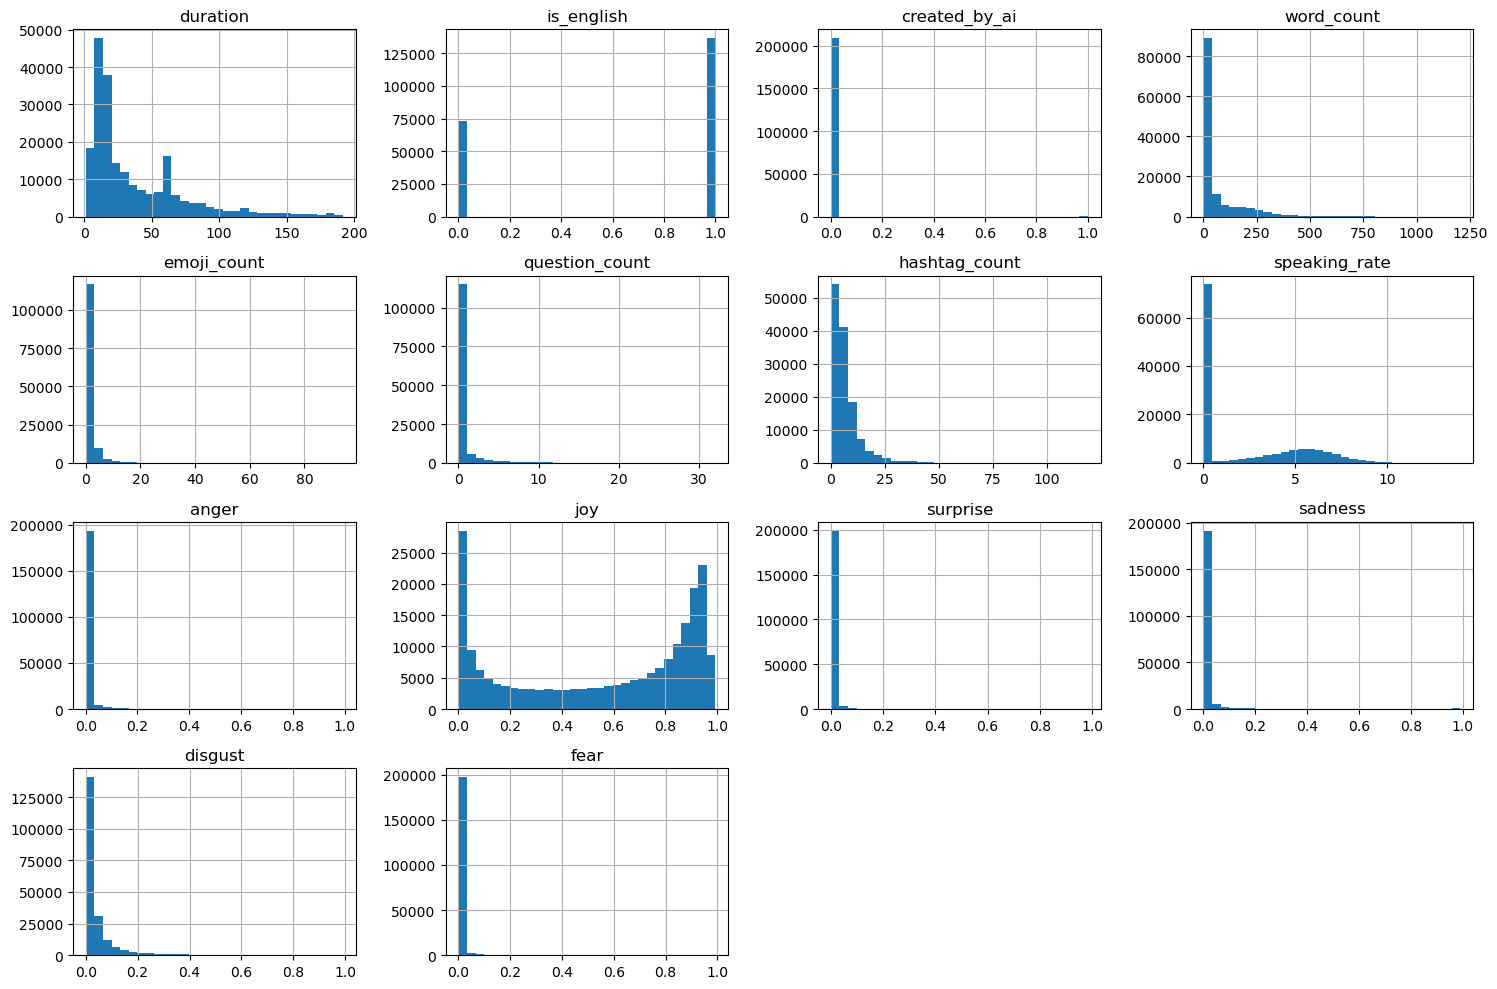

In [97]:
# Visualización de histogramas para las variables numéricas
numericas_video.hist(
    figsize=(15,10),
    bins=30
)

# Ajustar automáticamente el diseño de la figura para facilitar la lectura de los histogramas
plt.tight_layout()

# Guarda Gráfico de las distribuciones en la carpeta /graficos del proyecto
#plt.savefig(f"{ruta_graficos}/Nb01_11_distribuciones_variables_numericas.png", dpi=300, bbox_inches="tight")

# Mostrar los gráficos generados en pantalla
plt.show()

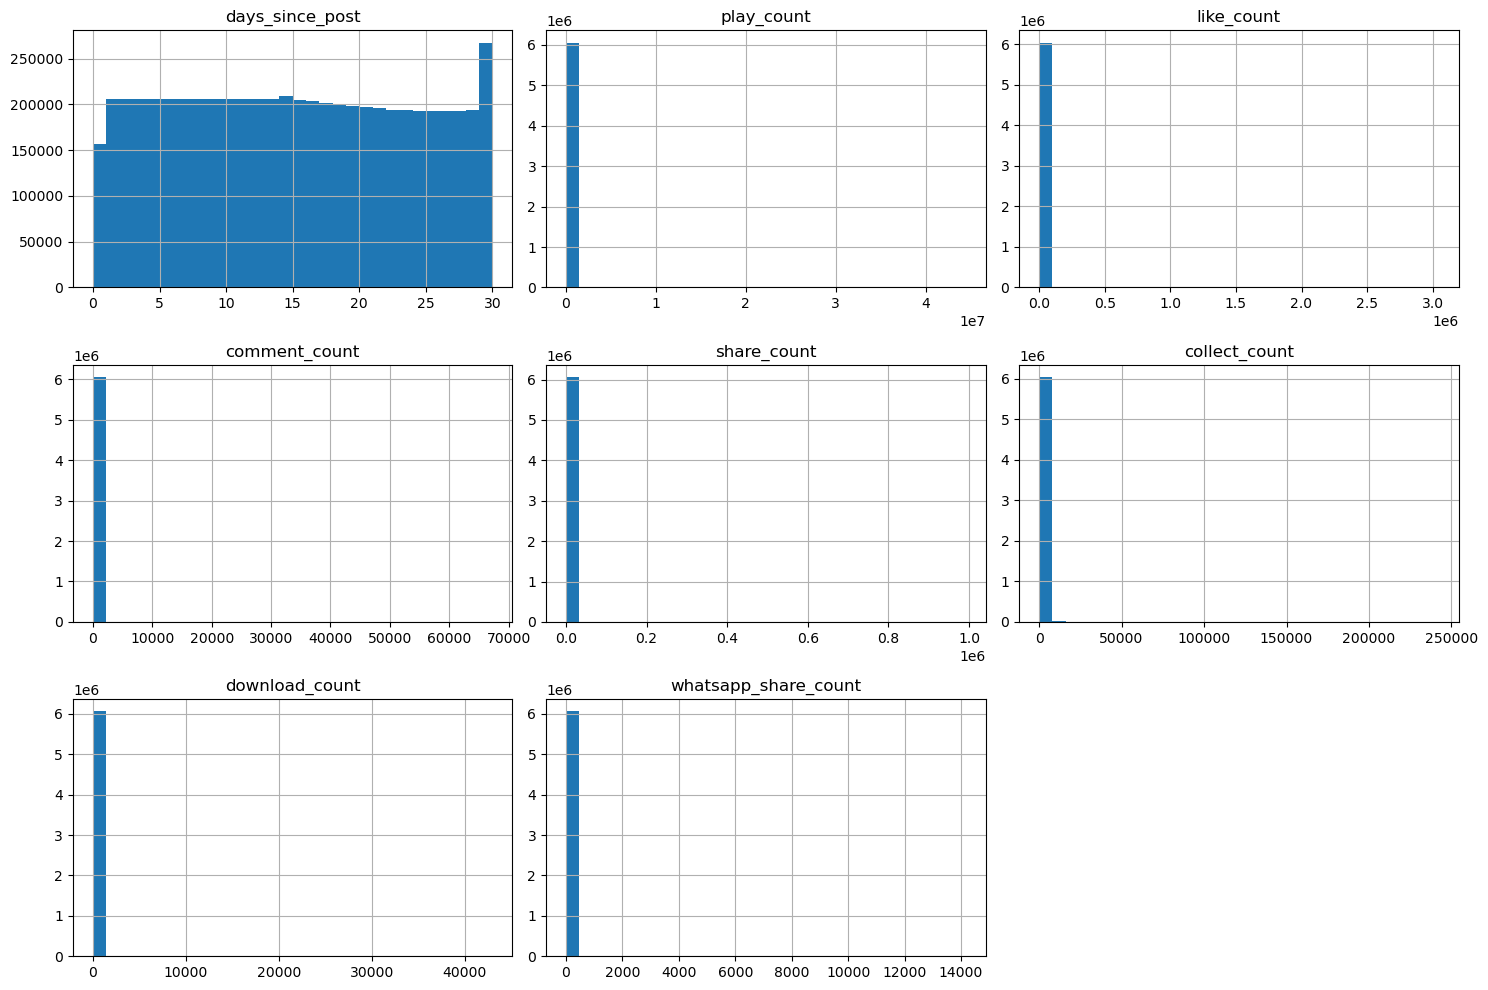

In [98]:
# Visualización de histogramas para las variables numéricas
numericas_engagement.hist(
    figsize=(15,10),
    bins=30
)

# Ajustar automáticamente el diseño de la figura para facilitar la lectura de los histogramas
plt.tight_layout()

# Guarda Gráfico de las distribuciones en la carpeta /graficos del proyecto
#plt.savefig(f"{ruta_graficos}/Nb01_11_distribuciones_variables_numericas.png", dpi=300, bbox_inches="tight")

# Mostrar los gráficos generados en pantalla
plt.show()

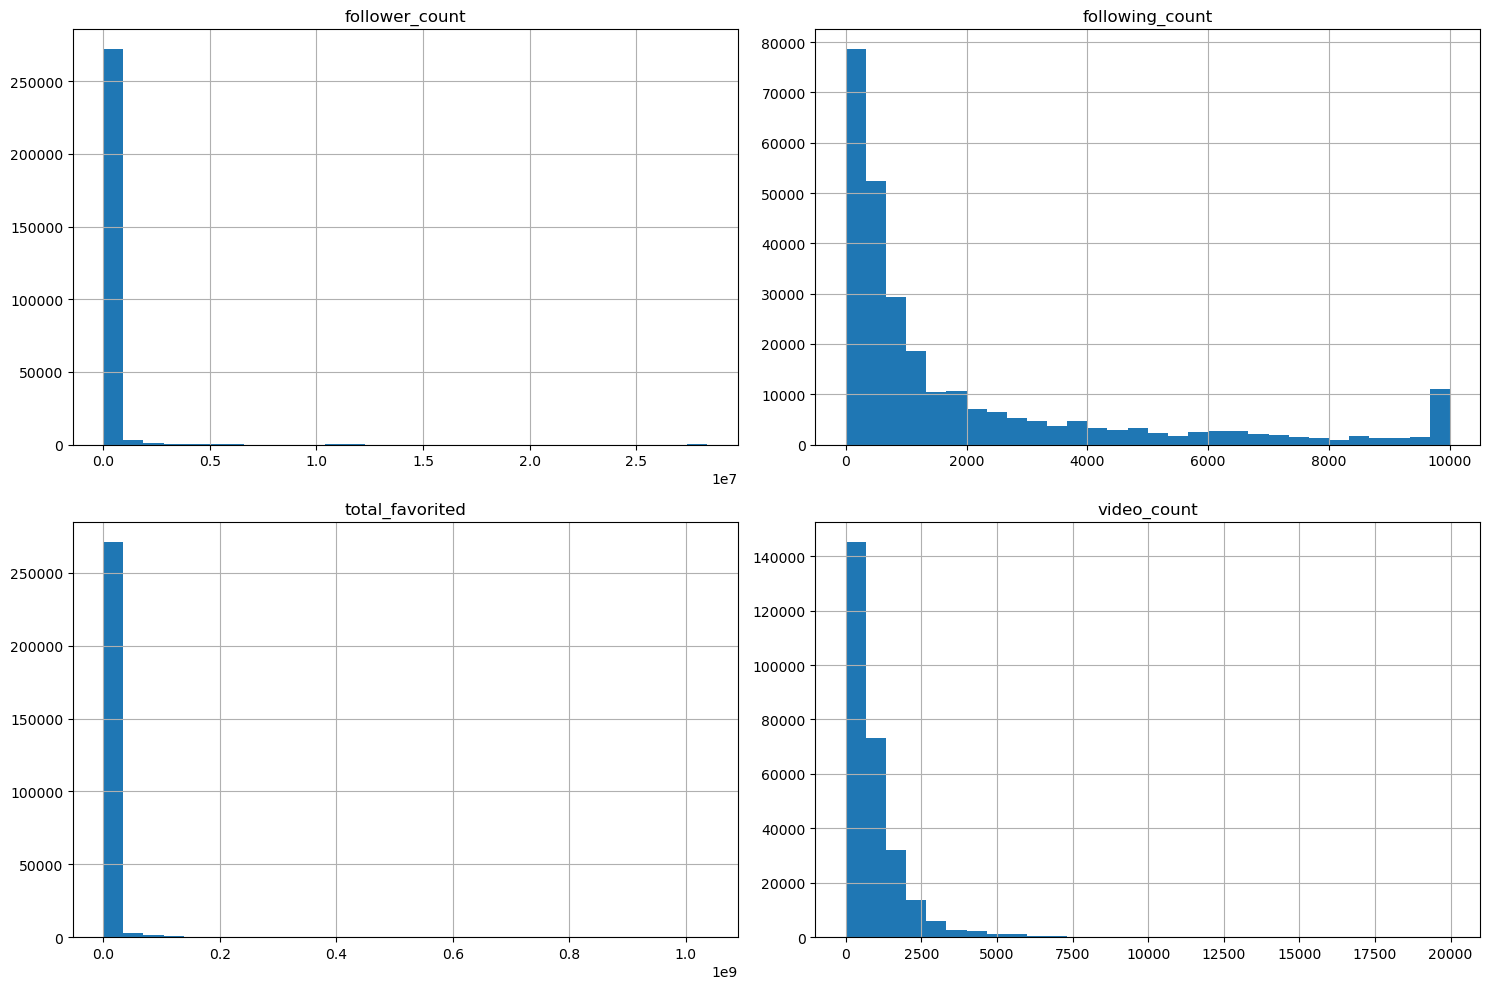

In [99]:
# Visualización de histogramas para las variables numéricas
numericas_creator.hist(
    figsize=(15,10),
    bins=30
)

# Ajustar automáticamente el diseño de la figura para facilitar la lectura de los histogramas
plt.tight_layout()

# Guarda Gráfico de las distribuciones en la carpeta /graficos del proyecto
#plt.savefig(f"{ruta_graficos}/Nb01_11_distribuciones_variables_numericas.png", dpi=300, bbox_inches="tight")

# Mostrar los gráficos generados en pantalla
plt.show()

#### **10.1. Análisis de Distribución de las Variables Numéricas**

Se generaron histogramas para todas las variables numéricas del dataset con el objetivo de analizar la distribución de los datos, identificar posibles sesgos, concentraciones de valores y detectar comportamientos anómalos que pudieran afectar al análisis posterior.

Interpretación de los resultados:
Distribución general
La mayoría de las variables presentan una distribución relativamente uniforme a lo largo de sus rangos de valores:

cpu_utilization
memory_usage
disk_io
network_latency
process_count
context_switches
cache_miss_rate
temperature
power_consumption
uptime
Esto indica que el dataset contiene observaciones distribuidas de forma equilibrada y que no existe una concentración excesiva de registros en intervalos específicos.

Caso particular: thread_count
La variable: thread_count
Presenta una distribución diferente al resto.

Se observa una mayor concentración de registros en valores bajos y medios, mientras que la frecuencia disminuye progresivamente a medida que aumenta el número de hilos.

Esto sugiere una distribución asimétrica (sesgada hacia la derecha), indicando que la mayoría de los sistemas operan con cantidades moderadas de hilos y sólo una proporción menor alcanza valores elevados.

#### **11.2. Conclusiones del Análisis de Distribución de las Variables Numéricas**

Las distribuciones observadas muestran que la mayoría de las métricas de rendimiento presentan una cobertura homogénea de sus respectivos rangos de valores, lo que favorece el análisis estadístico y el entrenamiento de modelos predictivos.

No obstante, las variables thread_count y especialmente status presentan comportamientos diferenciados que requerirán un análisis más detallado en las siguientes fases del proyecto.

Porque el histograma parece indicar que los valores de la variable status.

De cada 100 registros:

Aproximadamente 99 registros tienen valor 0.
Aproximadamente 1 registro tiene valor 1.
Si el dataset tiene 10.000 registros:

status = 0 → 9.903 registros
status = 1 → 97 registros
Interpretaciones para el Negocio:
Asumiendo que:
0 = Estado normal
1 = Incidencia / Estado crítico / Fallo
El dataset representa un escenario realista en monitorización IT:
La gran mayoría de los sistemas funcionan correctamente.
Los eventos anómalos o fallos son poco frecuentes.
El objetivo es precisamente detectar esos pocos casos problemáticos.

#### **12. Correlaciones**

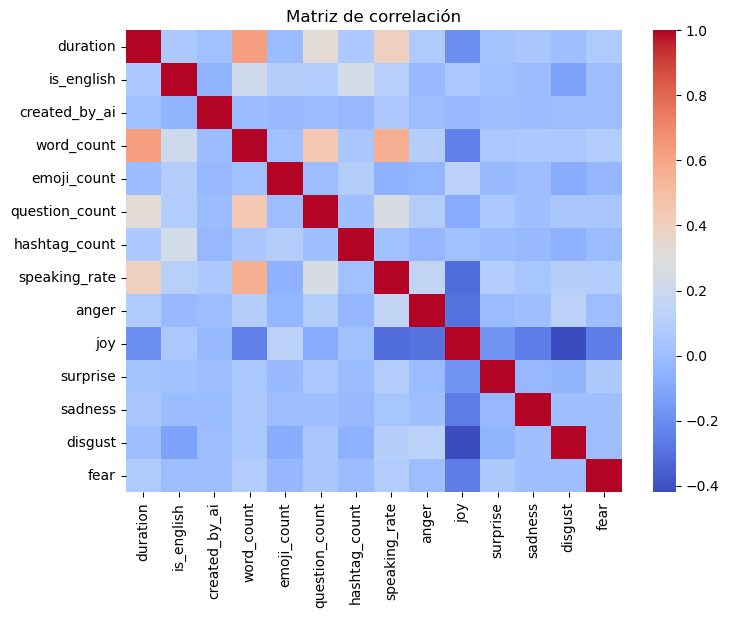

In [100]:
# Calcular la matriz de correlación entre las variables numéricas
corr = numericas_video.corr()

# Definir el tamaño de la figura donde se mostrará el mapa de calor
plt.figure(figsize=(8,6))

# Generar un mapa de calor para visualizar la intensidad de las correlaciones
sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

# Añadir un título descriptivo al gráfico
plt.title("Matriz de correlación")

# Guarda Gráfico de las distribuciones en la carpeta /graficos del proyecto
#plt.savefig(f"{ruta_graficos}/Nb01_12_matriz_correlacion.png", dpi=300, bbox_inches="tight")

# Mostrar el mapa de calor generado
plt.show()

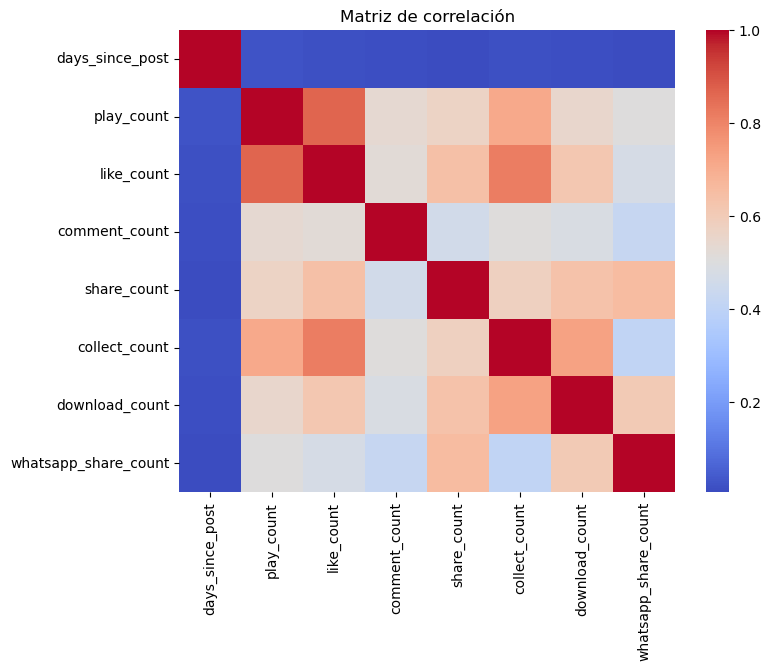

In [102]:
# Calcular la matriz de correlación entre las variables numéricas
corr = numericas_engagement.corr()

# Definir el tamaño de la figura donde se mostrará el mapa de calor
plt.figure(figsize=(8,6))

# Generar un mapa de calor para visualizar la intensidad de las correlaciones
sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

# Añadir un título descriptivo al gráfico
plt.title("Matriz de correlación")

# Guarda Gráfico de las distribuciones en la carpeta /graficos del proyecto
#plt.savefig(f"{ruta_graficos}/Nb01_12_matriz_correlacion.png", dpi=300, bbox_inches="tight")

# Mostrar el mapa de calor generado
plt.show()

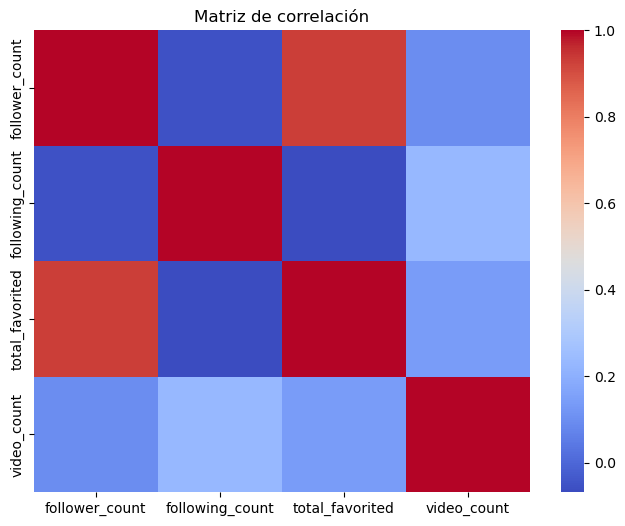

In [103]:
# Calcular la matriz de correlación entre las variables numéricas
corr = numericas_creator.corr()

# Definir el tamaño de la figura donde se mostrará el mapa de calor
plt.figure(figsize=(8,6))

# Generar un mapa de calor para visualizar la intensidad de las correlaciones
sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

# Añadir un título descriptivo al gráfico
plt.title("Matriz de correlación")

# Guarda Gráfico de las distribuciones en la carpeta /graficos del proyecto
#plt.savefig(f"{ruta_graficos}/Nb01_12_matriz_correlacion.png", dpi=300, bbox_inches="tight")

# Mostrar el mapa de calor generado
plt.show()

NO SE DONDE SE IMPLEMENTA LA VARIABLE OBJETIVO ASI QUE NI ZORRA

Ejemplo:
Muestra exactamente qué variables tienen más relación con status
corr["status"].sort_values(ascending=False)

#### **13. VALORES ATÍPICOS**

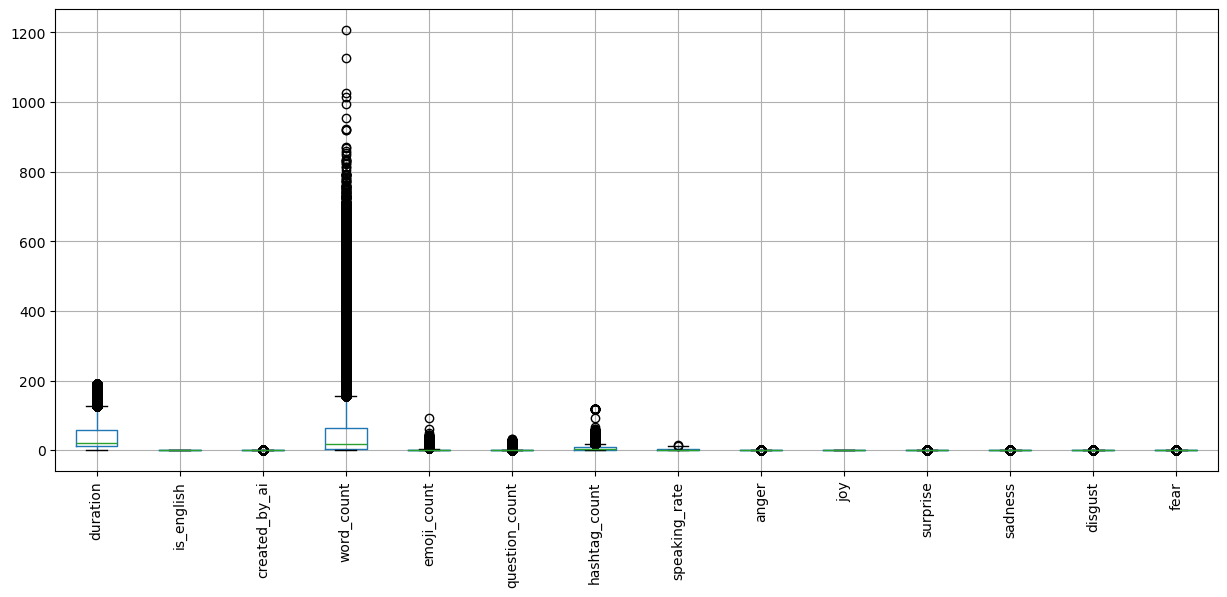

In [104]:
# Visualización de boxplots para las variables numéricas
numericas_video.boxplot(
    figsize=(15,6),
    rot=90
)

# Guarda Gráfico de los boxplots
#plt.savefig(f"{ruta_graficos}/Nb01_13_boxplots_valores_extremos.png", dpi=300, bbox_inches="tight")

# Ajustar automáticamente el diseño de la figura para facilitar la lectura de los boxplots
plt.show()

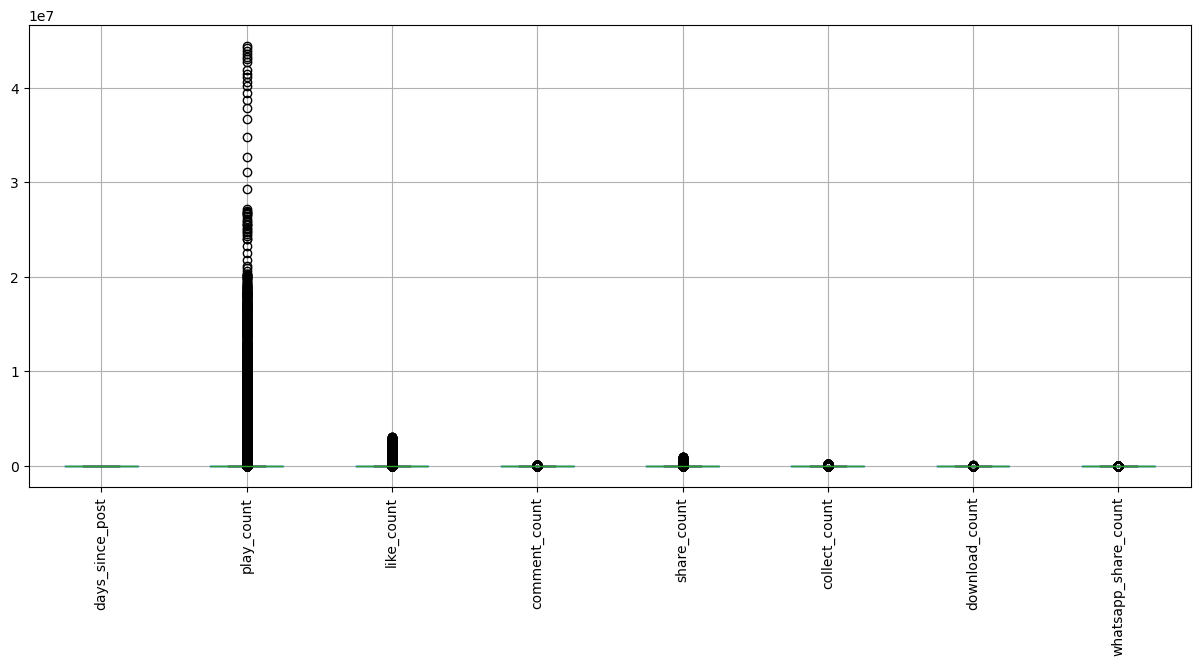

In [105]:
# Visualización de boxplots para las variables numéricas
numericas_engagement.boxplot(
    figsize=(15,6),
    rot=90
)

# Guarda Gráfico de los boxplots
#plt.savefig(f"{ruta_graficos}/Nb01_13_boxplots_valores_extremos.png", dpi=300, bbox_inches="tight")

# Ajustar automáticamente el diseño de la figura para facilitar la lectura de los boxplots
plt.show()

In [ ]:
# Visualización de boxplots para las variables numéricas
numericas_creator.boxplot(
    figsize=(15,6),
    rot=90
)
 
# Guarda Gráfico de los boxplots
#plt.savefig(f"{ruta_graficos}/Nb01_13_boxplots_valores_extremos.png", dpi=300, bbox_inches="tight")

# Ajustar automáticamente el diseño de la figura para facilitar la lectura de los boxplots
plt.show()

---
## **4. Preprocesamiento y Limpieza de Datos**

En esta fase, se realizará la limpieza del conjunto de datos teniendo en cuenta una serie de situaciones:

* Las columnas que no son relevantes respecto a la resolución del problema.
* Los registros duplicados o columnas repetidas.
* Determinar valores atípicos (outliers) en el conjunto de datos y realizar un análisis sobre la mejor estrategia.
* Los errores tipográficos en las variables categóricas.
* Los datos faltantes en algunas columnas.

---
#### **Columnas irrelevantes**

Las columnas irrelevantes pueden ser:
* Columnas que no tienen información relevante respecto al precio de la vivienda.
* Columnas categóricas o numéricas que contienen la misma información.
* Columnas que tienen información redudante o duplicada. 

---
#### **Registros duplicados o columnas repetidas**

---
#### **Valores atípicos (outliers) en las variables numéricas**

---
#### **Errores tipográficos en variables categoricas**

---
#### **Datos faltantes**

---
## **5. Análisis Exploratorio de Datos (EDA)**

---
## **6. Ingeniería de características (Feature Engineering)**

---
## **7. Modelado y Predicción con Machine Learning**